# Data cleaning

In [1]:
import pandas as pd
df=pd.read_csv("Teen_Mental_Health_Dataset.csv")
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [2]:
#shape of the table
df.shape

(1200, 13)

In [3]:
#datatypes in table
df.dtypes

age                           int64
gender                       object
daily_social_media_hours    float64
platform_usage               object
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level     object
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object

In [4]:
#• Missing Value Analysis
df.isnull().sum()
#df["age"].fillna(df["age"].mean(),inplace=True)

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [5]:
#Duplicate Record Analysis
#df.dropna()
df.duplicated().sum()

0

In [6]:
#Removing Unnecessary Columns
df.drop("depression_label",axis=1,inplace=True)

In [7]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2


#  Exploratory Data Analysis (EDA)

#  Pivot Table Analysis

In [8]:
#• Create business-focused pivot tables to identify patterns and trends.
pd.pivot_table(
    df,
index=["gender","age"],
values="daily_social_media_hours",
aggfunc=["sum","min","max","mean"]
)

sum                      min  \
           daily_social_media_hours daily_social_media_hours   
gender age                                                     
female 13                     401.0                      1.1   
       14                     336.5                      1.0   
       15                     399.8                      1.1   
       16                     369.3                      1.0   
       17                     458.8                      1.1   
       18                     343.8                      1.1   
       19                     330.9                      1.1   
male   13                     501.2                      1.1   
       14                     329.2                      1.2   
       15                     449.3                      1.0   
       16                     386.5                      1.1   
       17                     351.0                      1.1   
       18                     385.9                      1.0   
       19                     400.8                      1.2   

                                max                     mean  
           daily_social_media_hours daily_social_media_hours  
gender age                                                    
female 13                       8.0                 4.311828  
       14                       7.8                 4.314103  
       15                       8.0                 4.492135  
       16                       7.9                 4.796104  
       17                       8.0                 4.729897  
       18                       8.0                 4.244444  
       19                       7.9                 4.727143  
male   13                       8.0                 4.684112  
       14                       7.9                 4.389333  
       15                       8.0                 4.937363  
       16                       8.0                 4.494186  
       17                       8.0                 4.808219  
       18                       7.9                 4.240659  
       19                       8.0                 4.356522

In [9]:
pd.pivot_table(
    df,
index=["age","gender"],
values=["platform_usage","daily_social_media_hours"],
aggfunc=["min","max"]
)

min                                     max  \
           daily_social_media_hours platform_usage daily_social_media_hours   
age gender                                                                    
13  female                      1.1           Both                      8.0   
    male                        1.1           Both                      8.0   
14  female                      1.0           Both                      7.8   
    male                        1.2           Both                      7.9   
15  female                      1.1           Both                      8.0   
    male                        1.0           Both                      8.0   
16  female                      1.0           Both                      7.9   
    male                        1.1           Both                      8.0   
17  female                      1.1           Both                      8.0   
    male                        1.1           Both                      8.0   
18  female                      1.1           Both                      8.0   
    male                        1.0           Both                      7.9   
19  female                      1.1           Both                      7.9   
    male                        1.2           Both                      8.0   

                           
           platform_usage  
age gender                 
13  female         TikTok  
    male           TikTok  
14  female         TikTok  
    male           TikTok  
15  female         TikTok  
    male           TikTok  
16  female         TikTok  
    male           TikTok  
17  female         TikTok  
    male           TikTok  
18  female         TikTok  
    male           TikTok  
19  female         TikTok  
    male           TikTok

In [10]:
#How does depression label vary with daily social media hours?
pd.pivot_table(
    df,
index="platform_usage",
values=["daily_social_media_hours"],
aggfunc="mean"
)

,daily_social_media_hours
platform_usage,
Both,4.518414
Instagram,4.559367
TikTok,4.531156


In [11]:
#Do females report higher stress and anxiety levels than males?
pd.pivot_table(
    df,
index="gender",
values=["stress_level","anxiety_level"],
aggfunc=["min","max"]
)

min                        max             
       anxiety_level stress_level anxiety_level stress_level
gender                                                      
female             1            1            10           10
male               1            1            10           10

In [12]:
#Does platform usage affect academic performance?
pd.pivot_table(
    df,
index="platform_usage",
values=["academic_performance"],
aggfunc="sum"
)

,academic_performance
platform_usage,
Both,1163.30
Instagram,1231.15
TikTok,1194.01


In [13]:
# How does stress_level vary with daily social media hours?
pd.pivot_table(
    df,
index="stress_level",
values="daily_social_media_hours",
aggfunc="mean"
)

,daily_social_media_hours
stress_level,
1,4.592537
2,4.348148
3,4.850000
4,4.329496
5,4.234109
6,4.407018
7,4.579245
8,4.731731
9,4.513115


In [35]:
#Do people with high addiction_level sleep less?
pd.pivot_table(
    df,
index="addiction_level",
values="sleep_hours",
aggfunc=["mean","max","min"]
)

,mean,max,min
,sleep_hours,sleep_hours,sleep_hours
addiction_level,,,
1,6.513761,9.0,4.1
2,6.645833,9.0,4.0
3,6.588034,9.0,4.0
4,6.363248,9.0,4.1
5,6.397368,9.0,4.0
6,6.452239,9.0,4.1
7,6.513710,9.0,4.0
8,6.240909,8.9,4.0


In [15]:
# What’s the average academic performance for students with high vs low stress levels?
pd.pivot_table(
    df,
index="stress_level",
values="academic_performance",
aggfunc="mean"
)

,academic_performance
stress_level,
1,3.032836
2,2.966111
3,2.970172
4,3.007266
5,2.916357
6,3.050088
7,3.019434
8,2.930385
9,2.966393


# GroupBy Analysis


In [16]:
#What’s the average daily_social_media_hours, stress_level, and anxiety_level for each gender and age group?  
df.groupby(['gender', 'age'])['daily_social_media_hours', 'stress_level', 'anxiety_level'].mean()

C:\Users\PRASANTH KUMAR\AppData\Local\Temp\ipykernel_24840\1427579344.py:2: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  df.groupby(['gender', 'age'])['daily_social_media_hours', 'stress_level', 'anxiety_level'].mean()


daily_social_media_hours  stress_level  anxiety_level
gender age                                                       
female 13                   4.311828      5.333333       5.526882
       14                   4.314103      5.923077       5.487179
       15                   4.492135      5.483146       6.044944
       16                   4.796104      5.610390       5.532468
       17                   4.729897      5.164948       5.814433
       18                   4.244444      5.098765       5.641975
       19                   4.727143      5.428571       5.714286
male   13                   4.684112      5.570093       5.579439
       14                   4.389333      6.440000       5.173333
       15                   4.937363      4.791209       5.791209
       16                   4.494186      5.313953       5.744186
       17                   4.808219      5.178082       5.260274
       18                   4.240659      5.296703       5.219780
       19                   4.356522      5.771739       6.217391

In [17]:
#What’s the total daily social media hours spent by each platform’s users?
df.groupby('platform_usage')['daily_social_media_hours'].sum()

platform_usage
Both         1766.7
Instagram    1873.9
TikTok       1803.4
Name: daily_social_media_hours, dtype: float64

In [18]:
#What’s the average stress level and total number of users per gender?
df.groupby('gender').agg({'stress_level':'mean'})

,stress_level
gender,
female,5.422222
male,5.468293


In [19]:
#Which age group has the highest total screen time before sleep?
df.groupby('age')['screen_time_before_sleep'].sum() 

age
13    324.9
14    275.0
15    302.2
16    282.5
17    296.7
18    309.4
19    297.7
Name: screen_time_before_sleep, dtype: float64

In [20]:
df.groupby(['gender', 'anxiety_level']).agg({
    'stress_level':'mean',
    'daily_social_media_hours':'mean',
})

stress_level  daily_social_media_hours
gender anxiety_level                                        
female 1                  4.836364                  4.398182
       2                  5.584906                  4.656604
       3                  5.166667                  5.100000
       4                  5.985294                  4.523529
       5                  5.477273                  4.297727
       6                  5.064516                  4.027419
       7                  5.038462                  4.400000
       8                  5.442857                  4.478571
       9                  5.888889                  4.759259
       10                 5.589041                  4.524658
male   1                  5.260000                  4.172000
       2                  5.771930                  4.521053
       3                  4.956522                  4.663768
       4                  6.492063                  4.555556
       5                  5.262295                  4.459016
       6                  5.471429                  4.142857
       7                  5.210526                  4.645614
       8                  5.133333                  4.818333
       9                  5.457143                  4.492857
       10                 5.672414                  5.144828

In [21]:
df.groupby(["platform_usage","sleep_hours"])["academic_performance"].mean()

platform_usage  sleep_hours
Both            4.0            2.905000
                4.1            2.813750
                4.2            2.811538
                4.3            3.052500
                4.4            2.801000
                                 ...   
TikTok          8.6            2.841111
                8.7            3.094000
                8.8            3.082222
                8.9            3.124000
                9.0            3.007500
Name: academic_performance, Length: 153, dtype: float64

In [22]:
df.groupby(["social_interaction_level"])["stress_level","anxiety_level"].mean()

C:\Users\PRASANTH KUMAR\AppData\Local\Temp\ipykernel_24840\46776236.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  df.groupby(["social_interaction_level"])["stress_level","anxiety_level"].mean()


,stress_level,anxiety_level
social_interaction_level,,
high,5.512195,5.704607
low,5.349398,5.525301
medium,5.483173,5.687500


In [23]:
df.groupby('anxiety_level')[['daily_social_media_hours', 'sleep_hours']].mean()


,daily_social_media_hours,sleep_hours
anxiety_level,,
1,4.290476,6.537143
2,4.586364,6.554545
3,4.855285,6.365041
4,4.538931,6.461069
5,4.391429,6.292381
6,4.088636,6.400758
7,4.528440,6.563303
8,4.635385,6.657692
9,4.608871,6.155645


In [24]:
df.groupby(["age","gender"])["physical_activity"].count()

age  gender
13   female     93
     male      107
14   female     78
     male       75
15   female     89
     male       91
16   female     77
     male       86
17   female     97
     male       73
18   female     81
     male       91
19   female     70
     male       92
Name: physical_activity, dtype: int64

# Data Visualization

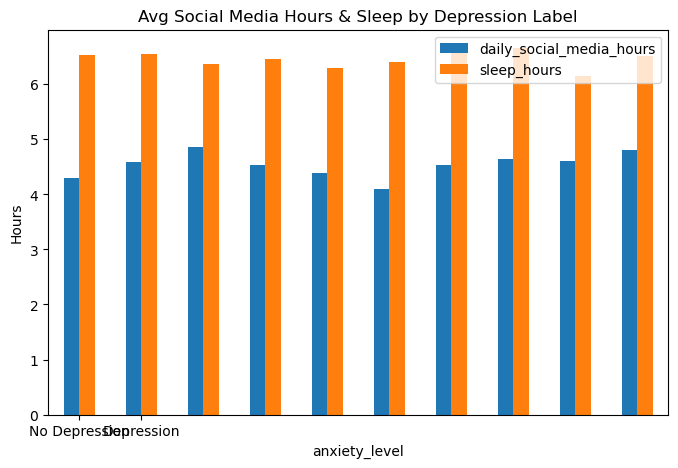

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

avg_data = df.groupby('anxiety_level')[['daily_social_media_hours', 'sleep_hours']].mean()

avg_data.plot(kind='bar', figsize=(8,5))
plt.title('Avg Social Media Hours & Sleep by Depression Label')
plt.ylabel('Hours')
plt.xticks([0, 1], ['No Depression', 'Depression'], rotation=0)
plt.show()

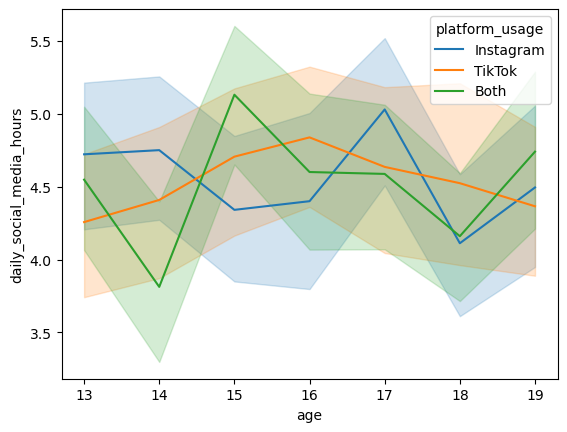

In [26]:
sns.lineplot(
data=df,
x="age",
y="daily_social_media_hours",
hue="platform_usage")
plt.show()

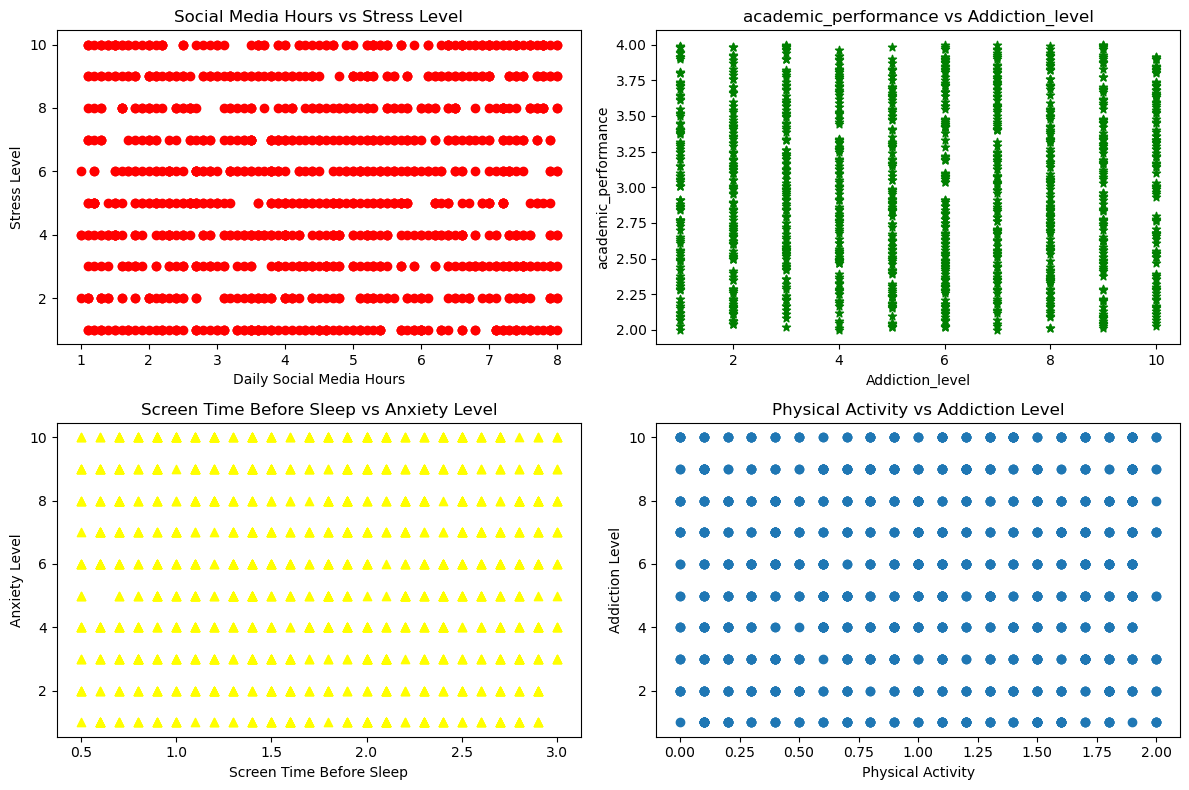

In [27]:
#scatterplot
plt.figure(figsize=(12,8))

# Scatter Plot 1
plt.subplot(2,2,1)
plt.scatter(df['daily_social_media_hours'], df['stress_level'],marker="o",color="red")
plt.title('Social Media Hours vs Stress Level')
plt.xlabel('Daily Social Media Hours')
plt.ylabel('Stress Level')

# Scatter Plot 2
plt.subplot(2,2,2)
plt.scatter(df['addiction_level'], df['academic_performance'],marker="*",color="g")
plt.title('academic_performance vs Addiction_level')
plt.ylabel('academic_performance')
plt.xlabel('Addiction_level')

# Scatter Plot 3
plt.subplot(2,2,3)
plt.scatter(df['screen_time_before_sleep'], df['anxiety_level'],marker="^",color="yellow")
plt.title('Screen Time Before Sleep vs Anxiety Level')
plt.xlabel('Screen Time Before Sleep')
plt.ylabel('Anxiety Level')

# Scatter Plot 4
plt.subplot(2,2,4)
plt.scatter(df['physical_activity'], df['addiction_level'])
plt.title('Physical Activity vs Addiction Level')
plt.xlabel('Physical Activity')
plt.ylabel('Addiction Level')

plt.tight_layout()
plt.show()

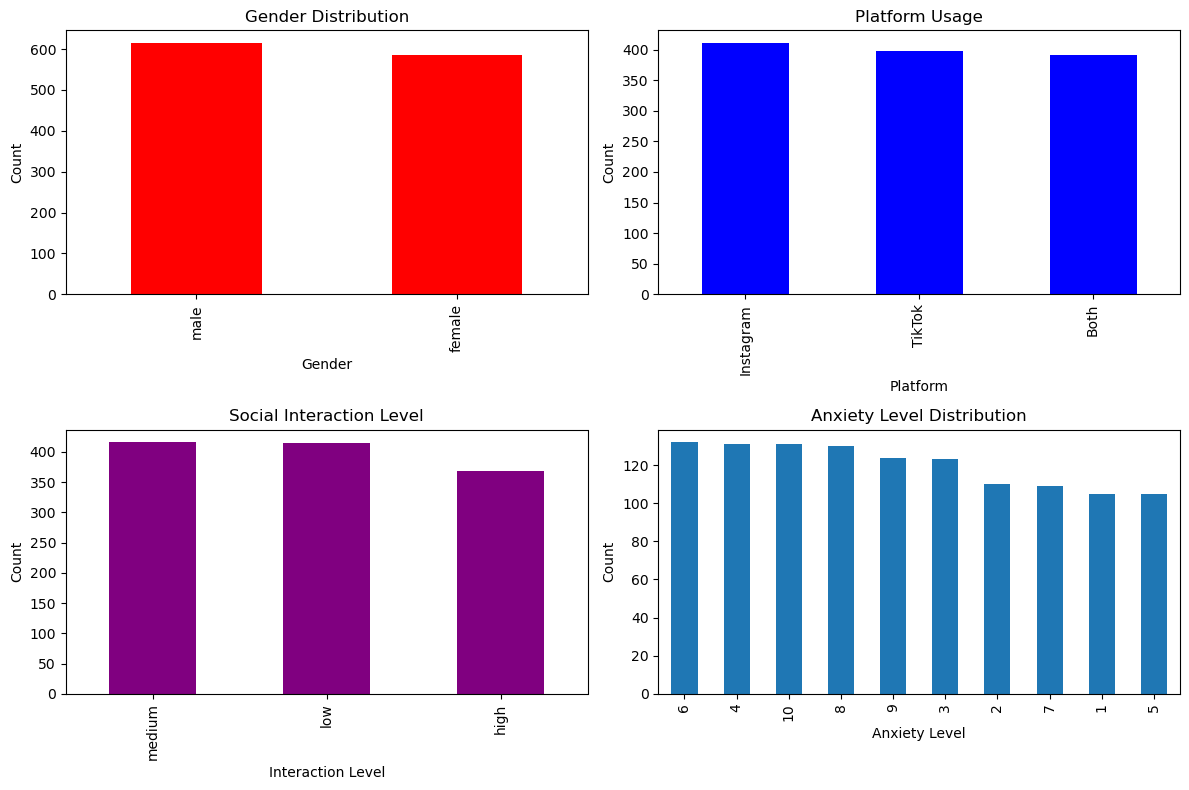

In [28]:
#Bar plot

plt.figure(figsize=(12,8))

# Bar Plot 1
plt.subplot(2,2,1)
df['gender'].value_counts().plot(kind='bar',color="r")
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')

# Bar Plot 2
plt.subplot(2,2,2)
df['platform_usage'].value_counts().plot(kind='bar',color="b")
plt.title('Platform Usage')
plt.xlabel('Platform')
plt.ylabel('Count')

# Bar Plot 3
plt.subplot(2,2,3)
df['social_interaction_level'].value_counts().plot(kind='bar',color="purple")
plt.title('Social Interaction Level')
plt.xlabel('Interaction Level')
plt.ylabel('Count')

# Bar Plot 4
plt.subplot(2,2,4)
df['anxiety_level'].value_counts().plot(kind='bar')
plt.title('Anxiety Level Distribution')
plt.xlabel('Anxiety Level')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

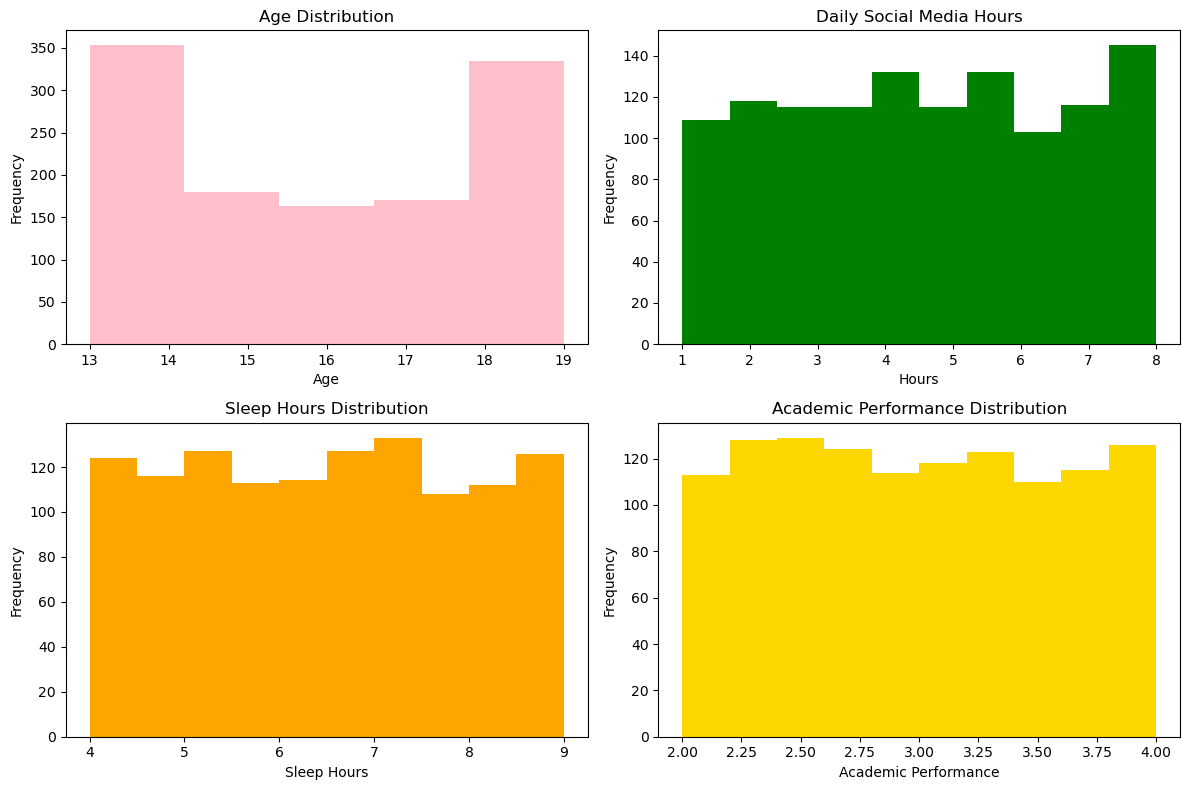

In [29]:
#Histogram
plt.figure(figsize=(12,8))

# Histogram 1
plt.subplot(2,2,1)
plt.hist(df['age'], bins=5,color="pink")
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Histogram 2
plt.subplot(2,2,2)
plt.hist(df['daily_social_media_hours'], bins=10,color="green")
plt.title('Daily Social Media Hours')
plt.xlabel('Hours')
plt.ylabel('Frequency')

# Histogram 3
plt.subplot(2,2,3)
plt.hist(df['sleep_hours'], bins=10,color="orange")
plt.title('Sleep Hours Distribution')
plt.xlabel('Sleep Hours')
plt.ylabel('Frequency')

# Histogram 4
plt.subplot(2,2,4)
plt.hist(df['academic_performance'], bins=10,color="gold")
plt.title('Academic Performance Distribution')
plt.xlabel('Academic Performance')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

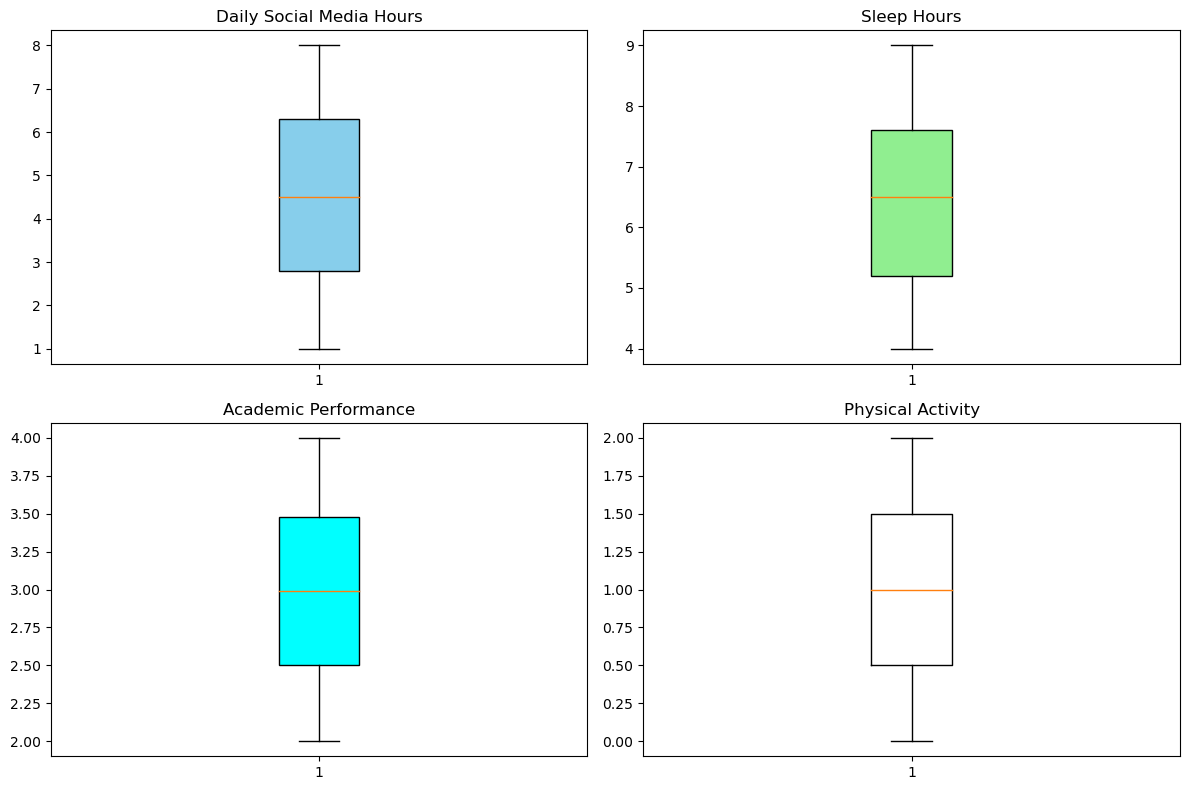

In [30]:
#boxplot

plt.figure(figsize=(12,8))

# Box Plot 1
plt.subplot(2,2,1)
plt.boxplot(df['daily_social_media_hours'],patch_artist=True,
            boxprops=dict(facecolor='skyblue'))
plt.title('Daily Social Media Hours')

# Box Plot 2
plt.subplot(2,2,2)
plt.boxplot(df['sleep_hours'],patch_artist=True,
            boxprops=dict(facecolor='lightgreen'))
plt.title('Sleep Hours')

# Box Plot 3
plt.subplot(2,2,3)
plt.boxplot(df['academic_performance'],patch_artist=True,
            boxprops=dict(facecolor='cyan'))
plt.title('Academic Performance')

# Box Plot 4
plt.subplot(2,2,4)
plt.boxplot(df['physical_activity'])
plt.title('Physical Activity')

plt.tight_layout()
plt.show()

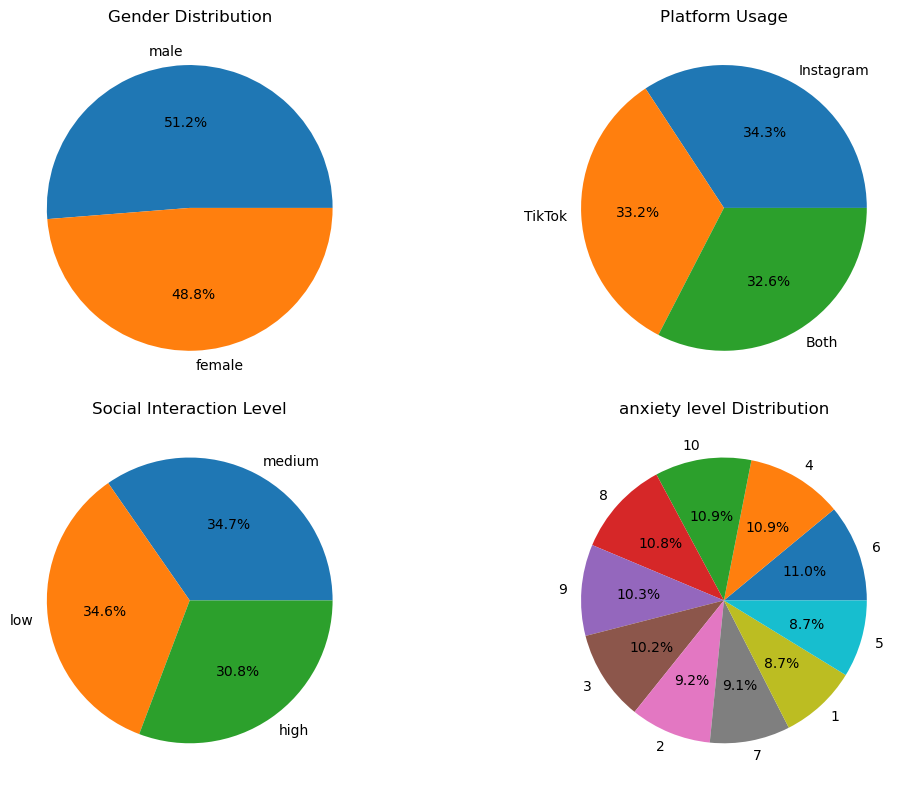

In [31]:
#Piechart
plt.figure(figsize=(12,8))

# Pie Chart 1
plt.subplot(2,2,1)
df['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title('Gender Distribution')
plt.ylabel('')

# Pie Chart 2
plt.subplot(2,2,2)
df['platform_usage'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title('Platform Usage')
plt.ylabel('')

# Pie Chart 3
plt.subplot(2,2,3)
df['social_interaction_level'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title('Social Interaction Level')
plt.ylabel('')

# Pie Chart 4
plt.subplot(2,2,4)
df['anxiety_level'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title('anxiety level Distribution')
plt.ylabel('')

plt.tight_layout()
plt.show()

#  Correlation Analysis

In [32]:
#correlation matrix
corr=df.corr(numeric_only=True)
print(corr)

                               age  daily_social_media_hours  sleep_hours  \
age                       1.000000                 -0.006635     0.001530   
daily_social_media_hours -0.006635                  1.000000    -0.009472   
sleep_hours               0.001530                 -0.009472     1.000000   
screen_time_before_sleep  0.075612                  0.035777     0.010235   
academic_performance     -0.013973                  0.013179     0.021866   
physical_activity         0.011086                  0.025546     0.012701   
stress_level             -0.031208                  0.030698    -0.010979   
anxiety_level             0.026363                  0.027835    -0.011879   
addiction_level           0.038265                 -0.024964    -0.054838   

                          screen_time_before_sleep  academic_performance  \
age                                       0.075612             -0.013973   
daily_social_media_hours                  0.035777              0.013179   
s

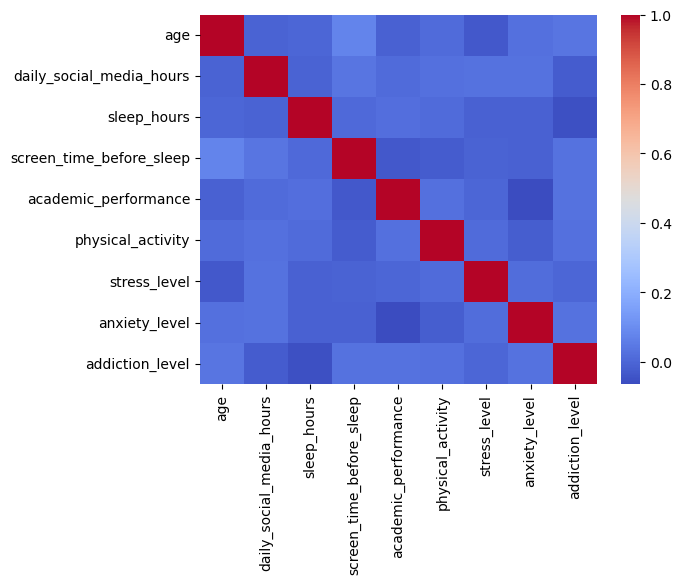

In [33]:
#Heatmap using correlation
sns.heatmap(
corr,cmap="coolwarm")
plt.show()